# table: mnist et al.

project = ```iP-VAE```, host = ```any```, device = ```any```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


def _load_df(files, info_keys=None):
    info_keys = info_keys or [
        'dataset', 'type', 'latent_act', 'str_model', 'archi',
        'seq_len', 'kl_beta', 'n_latents', 'seed',
    ]
    
    df = collections.defaultdict(list)
    for f in tqdm(files):
        if 't-2_b-2' in f:
            continue
        try:
            load = np.load(
                pjoin(results_dir, f),
                allow_pickle=True,
            ).item()
        except EOFError:
            print(f"EOFError:\n{f}")
            continue
    
        info, results = load['info'], load['results']
        # dataset dims: used for MSE perdim calculation
        channel_sz, pixel_sz, _ = dataset_dims(info['dataset'])
        total_dims = channel_sz * pixel_sz ** 2
    
        is_amortized = 'amort' in f or info.get('seq_len', 0) == 1
        is_pcn = 'pcn_' in f or 'pc' in info['str_model']

        if is_amortized or is_pcn:
            vals = {
                'r2': results['r2'],
                'mse': results['mse'],
                'mse_perdim': results['mse'] / total_dims * 1e3,
                '%-zeros': results['%-zeros'],
                'accu': results['clf_accuracy']['vld'],
                'n_params': info['n_params'],
            }
        else:
            info['n_latents'] = info['n_latents'][0]
            results_vld = results['results_xtract']['vld']
            vals = {
                'r2': results_vld['r2'][-1],
                'mse': results_vld['mse'][-1],
                'mse_perdim': results_vld['mse'][-1] / total_dims * 1e3,
                '%-zeros': np.mean(results_vld['samples'][:, -1, :] == 0.0),
                'accu': results['clf_accuracy']['vld'][1000],
                'n_params': info['n_params'],
            }
    
        # info
        for k in info_keys:
            df[k].append(info.get(k, None))
        df['amort'].append(is_amortized)
    
        # results
        for k, v in vals.items():
            df[k].append(v)

    df = pd.DataFrame(df)
    return df


def _prep_df_table(df: pd.DataFrame, dataset: str, num_seeds: int = 5):
    selected_seq_len = {
        'poisson': 128,
        'gaussian': 64,
        'gaussian+relu': 32,
        'poisson+amort': 1,
        'gaussian+amort': 1,
        'gaussian+relu+amort': 1,
        'pc': None,
        'ipc': None,
        # 'dcpc': None,
    }
    n_latents = 512
    allowed_archi = ['<grad|lin>', '<conv+b|conv+b>']

    df_table = []
    for str_model, seq_len in selected_seq_len.items():
        _df = df.loc[
            (df['dataset'] == dataset) &
            (df['str_model'] == str_model)
        ]
        if seq_len is not None:  # for non-PCN models
            _df = _df.loc[
                (_df['seq_len'] == seq_len) &
                (_df['kl_beta'] == seq_len) &
                (df['n_latents'] == n_latents) &
                (_df['archi'].isin(allowed_archi))
            ]
        _df = _df.sort_values(by=['seed'])
        # display(_df)
        assert len(_df) >= num_seeds
        _df = _df.iloc[-num_seeds:]
        df_table.append(_df)

    df_table = pd.concat(df_table, axis=0)
    df_table.reset_index(drop=True, inplace=True)
    return df_table

## Results & Figs dir

In [3]:
pal_models = get_palette_models()

results_dir = pjoin(tmp_dir, 'results_2025-03')
figs_dir = pjoin(fig_base_dir, 'results_2025-03')

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

len(os.listdir(results_dir)), len(os.listdir(figs_dir))

(624, 0)

## Main df (MNIST et al.)

In [4]:
files = [
    f for f in os.listdir(results_dir) if
    any(item in f for item in ('MNIST', 'SVHN', 'pcn_'))
]
files = sorted(files, key=alphanum_sort_key)

df = _load_df(files)
df.shape

100%|█████████████████████████████████████████| 208/208 [01:10<00:00,  2.93it/s]


(207, 16)

## table: MNIST

In [5]:
df_table = _prep_df_table(df, 'MNIST')
df_table['accu'] *= 100
df_table.shape

(40, 16)

In [6]:
save_obj(
    obj=df_table,
    file_name='df_table',
    save_dir='/home/hadi/Dropbox/git/IterativeVAE/results',
    mode='df',
)

[PROGRESS] 'df_table.df' saved at
/home/hadi/Dropbox/git/IterativeVAE/results

In [11]:
from figures.table import table_mnist

_ = table_mnist(df_table)

### iterative\\VAE
--------------------------------------------------

\begin{tabular}{c}
    iterative\\VAE
\end{tabular}
&
\begin{tabular}{l}
    \ipvae \\ 
    \igvae \\ 
    \igreluvae
\end{tabular}
&
\begin{tabularx}{\mycolwidth}{CC}
    \entry{4.39}{.04} & \entry{.951}{.000} \\ 
    \entry{7.63}{.02} & \entry{.914}{.000} \\ 
    \entry{8.45}{.92} & \entry{.906}{.011}
\end{tabularx}
&
\begin{tabular}{c}
    \entry{.84}{.00} \\ 
    \entry{.00}{.00} \\ 
    \entry{.78}{.05}
\end{tabular}
&
\begin{tabular}{c}
    \entry{96.46}{.11} \\ 
    \entry{92.73}{.14} \\ 
    \entry{95.74}{.43}
\end{tabular}
&
\begin{tabular}{c}
    $0.40~M$ \\ 
    $0.40~M$ \\ 
    $0.40~M$
\end{tabular}

--------------------------------------------------

### amortized\\VAE
--------------------------------------------------

\begin{tabular}{c}
    amortized\\VAE
\end{tabular}
&
\begin{tabular}{l}
    \pvae \\ 
    \gvae \\ 
    \greluvae
\end{tabular}
&
\begin{tabularx}{\mycolwidth}{CC}
    \entry{25.48}{.24} & \entry{.713}{.002} \\ 
    \entry{14.40}{.19} & \entry{.841}{.002} \\ 
    \entry{17.13}{.20} & \entry{.809}{.002}
\end{tabularx}
&
\begin{tabular}{c}
    \entry{.84}{.00} \\ 
    \entry{.00}{.00} \\ 
    \entry{.50}{.00}
\end{tabular}
&
\begin{tabular}{c}
    \entry{97.89}{.34} \\ 
    \entry{95.75}{2.19} \\ 
    \entry{95.41}{1.52}
\end{tabular}
&
\begin{tabular}{c}
    $6.79~M$ \\ 
    $6.93~M$ \\ 
    $6.93~M$
\end{tabular}

--------------------------------------------------

### PCN
--------------------------------------------------

\begin{tabular}{c}
    PCN
\end{tabular}
&
\begin{tabular}{l}
    PC \cite{rao1999predictive} \\ 
    iPC  \cite{salvatori2024ipc}
\end{tabular}
&
\begin{tabularx}{\mycolwidth}{CC}
    \entry{9.24}{.03} & \entry{.896}{.000} \\ 
    \entry{9.08}{.00} & \entry{.898}{.000}
\end{tabularx}
&
\begin{tabular}{c}
    \entry{.00}{.00} \\ 
    \entry{.00}{.00}
\end{tabular}
&
\begin{tabular}{c}
    \entry{90.74}{.26} \\ 
    \entry{91.60}{.10}
\end{tabular}
&
\begin{tabular}{c}
    $0.13~M$ \\ 
    $0.13~M$
\end{tabular}

--------------------------------------------------

In [7]:
_df = df_table.loc[df_table['str_model'] == 'poisson']
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
0,MNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,0,False,0.951021,3.435594,4.382135,0.844174,0.9637,403217
1,MNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,1,False,0.951163,3.428769,4.373429,0.843293,0.9646,403217
2,MNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,2,False,0.950543,3.470668,4.426873,0.844749,0.9653,403217
3,MNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,3,False,0.951094,3.429352,4.374174,0.844411,0.9645,403217
4,MNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,4,False,0.951042,3.429271,4.374070,0.843090,0.9648,403217


In [8]:
data = np.asarray(_df['r2'])
from analysis.stats import mu_and_err

In [9]:
mu_and_err(data, fmt='0.3f')

('\\entry{.951}{.000}', 0.9509503841400146, 0.0004218819924295782)

In [10]:
mu_and_err(data, fmt='0.2g')

('\\entry{.95}{.00042}', 0.9509503841400146, 0.0004218384216596613)

## Check on all datasets

In [5]:
selected_seq_len = dict(
    MNIST={'poisson': 128, 'gaussian': 64, 'gaussian+relu': 32},
    EMNIST={'poisson': 128, 'gaussian': 64, 'gaussian+relu': 32},
    FashionMNIST={'poisson': 128, 'gaussian': 64, 'gaussian+relu': 16},
)

### (1) MNIST

In [6]:
dataset = 'MNIST'

In [7]:
_df = df.loc[
    (df['dataset'] == dataset) &
    (df['str_model'] == 'poisson') &
    (df['seq_len'] == selected_seq_len[dataset]['poisson']) &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.sort_values(by=['seed'])
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
184,MNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,0,False,0.951051,3.433230,4.379119,0.844021,0.9647,403217
183,MNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,0,False,0.951021,3.435594,4.382135,0.844174,0.9637,403217
186,MNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,1,False,0.951163,3.428769,4.373429,0.843293,0.9646,403217
181,MNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,2,False,0.950543,3.470668,4.426873,0.844749,0.9653,403217
182,MNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,3,False,0.951094,3.429352,4.374174,0.844411,0.9645,403217
185,MNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,4,False,0.951042,3.429271,4.374070,0.843090,0.9648,403217


In [8]:
_df = df.loc[
    (df['dataset'] == dataset) &
    (df['str_model'] == 'gaussian') &
    (df['seq_len'] == selected_seq_len[dataset]['gaussian']) &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.sort_values(by=['seed'])
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
110,MNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,0,False,0.913787,5.966973,7.610935,0.000000e+00,0.9266,403730
114,MNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,0,False,0.913430,5.993700,7.645025,0.000000e+00,0.9279,403730
111,MNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,1,False,0.913568,5.980465,7.628145,1.953125e-07,0.9275,403730
112,MNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,2,False,0.913737,5.969987,7.614780,0.000000e+00,0.9276,403730
115,MNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,3,False,0.913583,5.977976,7.624970,0.000000e+00,0.9259,403730
113,MNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,4,False,0.913681,5.971826,7.617124,0.000000e+00,0.9274,403730


In [9]:
_df = df.loc[
    (df['dataset'] == dataset) &
    (df['str_model'] == 'gaussian+relu') &
    (df['seq_len'] == selected_seq_len[dataset]['gaussian+relu']) &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.sort_values(by=['seed'])
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
53,MNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,0,False,0.909860,6.351058,8.100840,0.785737,0.9562,403730
54,MNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,1,False,0.907833,6.497510,8.287640,0.828471,0.9593,403730
57,MNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,2,False,0.894832,7.317481,9.333522,0.748978,0.9538,403730
55,MNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,3,False,0.907523,6.481063,8.266662,0.779657,0.9588,403730
56,MNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,3,False,0.907523,6.481063,8.266662,0.779657,0.9588,403730


### (2) EMNIST

In [10]:
dataset = 'EMNIST'

In [11]:
_df = df.loc[
    (df['dataset'] == dataset) &
    (df['str_model'] == 'poisson') &
    (df['seq_len'] == selected_seq_len[dataset]['poisson']) &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.sort_values(by=['seed'])
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
148,EMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,0,False,0.961821,3.030123,3.864952,0.815951,0.863558,403217
149,EMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,10,False,0.961657,3.043882,3.882503,0.818667,0.863413,403217
150,EMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,11,False,0.961897,3.027093,3.861088,0.817089,0.860144,403217
151,EMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,12,False,0.961662,3.042225,3.880389,0.816756,0.856971,403217
152,EMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,13,False,0.961828,3.029887,3.864652,0.818462,0.862837,403217


In [12]:
_df = df.loc[
    (df['dataset'] == dataset) &
    (df['str_model'] == 'gaussian') &
    (df['seq_len'] == selected_seq_len[dataset]['gaussian']) &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.sort_values(by=['seed'])
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
91,EMNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,10,False,0.920372,6.220109,7.933812,0.0,0.740673,403730
92,EMNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,11,False,0.920309,6.227000,7.942602,0.0,0.737019,403730
93,EMNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,12,False,0.920367,6.218517,7.931782,0.0,0.736394,403730
94,EMNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,13,False,0.920476,6.209540,7.920332,0.0,0.736635,403730
95,EMNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,14,False,0.920267,6.232833,7.950043,0.0,0.736202,403730


In [13]:
_df = df.loc[
    (df['dataset'] == dataset) &
    (df['str_model'] == 'gaussian+relu') &
    (df['seq_len'] == selected_seq_len[dataset]['gaussian+relu']) &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.sort_values(by=['seed'])
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
33,EMNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,10,False,0.001177,81.322136,103.727214,0.867438,0.653942,403730
34,EMNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,11,False,0.880338,9.368383,11.949469,0.735452,0.794423,403730
35,EMNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,12,False,0.902256,7.680050,9.795983,0.731495,0.821731,403730
36,EMNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,13,False,0.873620,9.890009,12.614807,0.741216,0.797500,403730
37,EMNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,14,False,0.416136,46.833851,59.737055,0.821149,0.779760,403730


### (3) FashionMNIST

In [14]:
dataset = 'FashionMNIST'

In [15]:
_df = df.loc[
    (df['dataset'] == dataset) &
    (df['str_model'] == 'poisson') &
    (df['seq_len'] == selected_seq_len[dataset]['poisson']) &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.sort_values(by=['seed'])
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
170,FashionMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,0,False,0.944329,3.585687,4.573580,0.723120,0.8721,403217
171,FashionMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,1,False,0.944319,3.587626,4.576053,0.719014,0.8687,403217


In [16]:
_df = df.loc[
    (df['dataset'] == dataset) &
    (df['str_model'] == 'gaussian') &
    (df['seq_len'] == selected_seq_len[dataset]['gaussian']) &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.sort_values(by=['seed'])
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
99,FashionMNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,0,False,0.900932,6.604539,8.424157,0.0,0.8507,403730
100,FashionMNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,10,False,0.900795,6.613887,8.436081,0.0,0.8512,403730
101,FashionMNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,11,False,0.900668,6.625883,8.451381,0.0,0.8485,403730
102,FashionMNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,12,False,0.900668,6.626437,8.452088,0.0,0.8513,403730
103,FashionMNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,13,False,0.900874,6.610906,8.432278,0.0,0.8498,403730
104,FashionMNIST,gaussian,None,gaussian,<grad|lin>,64,64.0,512,14,False,0.900506,6.630065,8.456716,0.0,0.8502,403730


In [17]:
_df = df.loc[
    (df['dataset'] == dataset) &
    (df['str_model'] == 'gaussian+relu') &
    (df['seq_len'] == selected_seq_len[dataset]['gaussian+relu']) &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.sort_values(by=['seed'])
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
40,FashionMNIST,gaussian,relu,gaussian+relu,<grad|lin>,16,16.0,512,0,False,0.887834,7.633080,9.736072,0.684517,0.8585,403730
41,FashionMNIST,gaussian,relu,gaussian+relu,<grad|lin>,16,16.0,512,10,False,0.884951,7.848104,10.010337,0.638761,0.8594,403730
42,FashionMNIST,gaussian,relu,gaussian+relu,<grad|lin>,16,16.0,512,11,False,0.888353,7.588313,9.678970,0.700236,0.8615,403730
43,FashionMNIST,gaussian,relu,gaussian+relu,<grad|lin>,16,16.0,512,12,False,0.880108,8.148330,10.393278,0.603456,0.8565,403730
44,FashionMNIST,gaussian,relu,gaussian+relu,<grad|lin>,16,16.0,512,13,False,0.888243,7.563378,9.647166,0.721551,0.8648,403730
45,FashionMNIST,gaussian,relu,gaussian+relu,<grad|lin>,16,16.0,512,14,False,0.888545,7.572916,9.659331,0.698350,0.8596,403730


In [70]:
dataset = 'EMNIST'

_df = df.loc[
    (df['dataset'] == dataset) &
    (df['str_model'] == 'gaussian+relu') &
    (df['seq_len'] == 16) &  # selected_seq_len[dataset]['gaussian+relu']) &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.sort_values(by=['seed'])
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
28,EMNIST,gaussian,relu,gaussian+relu,<grad|lin>,16,16.0,512,0,False,0.912332,7.028566,8.965008,0.831962,0.810865,403730


In [71]:
from analysis.stats import mu_and_err
mu_and_err(_df['mse_perdim'])

('\\entry{9.0}{.0}', 8.965007504638361, 0)

## Etc

In [12]:
_df = df.loc[
    (df['dataset'] == 'EMNIST') &
    (df['str_model'] == 'poisson') &
    (df['seq_len'] == 128) &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.sort_values(by=['seed'])
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
144,EMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,0,False,0.961821,3.030123,3.864952,0.815951,0.863558,403217
145,EMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,10,False,0.961657,3.043882,3.882503,0.818667,0.863413,403217
146,EMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,11,False,0.961897,3.027093,3.861088,0.817089,0.860144,403217
147,EMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,12,False,0.961662,3.042225,3.880389,0.816756,0.856971,403217
148,EMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,13,False,0.961828,3.029887,3.864652,0.818462,0.862837,403217


EMNIST, supervised baseline:
- dense acc: 0.8999885320663452
- cnn acc: 0.8907157778739929
- cnn val_acc: 0.8816697001457214
- dense val_acc: 0.8783264756202698

In [16]:
df.loc[
    (df['dataset'] == 'FashionMNIST') &
    (df['str_model'] == 'poisson') &
    (df['seq_len'] == df['kl_beta'])
]

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
145,FashionMNIST,poisson,None,poisson,<grad|lin>,4,4.0,512,0,False,-17224.804688,2.545182e+06,3.246406e+06,0.935643,0.7917,403217
146,FashionMNIST,poisson,None,poisson,<grad|lin>,4,4.0,512,1,False,0.835979,1.118213e+01,1.426293e+01,0.935419,0.7781,403217
147,FashionMNIST,poisson,None,poisson,<grad|lin>,4,4.0,512,2,False,0.834518,1.128817e+01,1.439818e+01,0.933967,0.6591,403217
148,FashionMNIST,poisson,None,poisson,<grad|lin>,4,4.0,512,3,False,-508400.843750,5.591072e+07,7.131469e+07,0.931610,0.5679,403217
149,FashionMNIST,poisson,None,poisson,<grad|lin>,4,4.0,512,4,False,-385749.375000,4.480110e+07,5.714426e+07,0.930474,0.6222,403217
150,FashionMNIST,poisson,None,poisson,<grad|lin>,8,8.0,512,0,False,0.871443,8.542669e+00,1.089626e+01,0.923595,0.8089,403217
152,FashionMNIST,poisson,None,poisson,<grad|lin>,16,16.0,512,0,False,0.899127,6.599153e+00,8.417286e+00,0.877430,0.8612,403217
153,FashionMNIST,poisson,None,poisson,<grad|lin>,16,16.0,512,1,False,0.809397,1.356064e+01,1.729674e+01,0.878674,0.8625,403217
155,FashionMNIST,poisson,None,poisson,<grad|lin>,32,32.0,512,1,False,0.851756,1.016973e+01,1.297159e+01,0.812223,0.8700,403217
158,FashionMNIST,poisson,None,poisson,<grad|lin>,64,64.0,512,1,False,0.888382,7.481263e+00,9.542427e+00,0.783917,0.8728,403217


In [12]:
_df = df.loc[df['dataset'] == 'SVHN']
_df = _df.loc[_df['mse'] < 1000]
_df

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
57,SVHN,gaussian,relu,gaussian+relu,<grad|lin>,16,16.0,512,0,False,0.416006,7.055711,6.890343,0.527956,0.350108,526850
113,SVHN,gaussian,None,gaussian,<grad|lin>,16,16.0,512,0,False,0.776712,2.726341,2.662442,0.000000,0.234404,526850
182,SVHN,poisson,None,poisson,<grad|lin>,128,1024.0,1024,0,False,0.912477,1.236708,1.207723,0.703988,0.749539,1051649
183,SVHN,poisson,None,poisson,<grad|lin>,128,128.0,512,0,False,0.946373,0.710175,0.693530,0.679319,0.651890,526337


In [25]:
df.loc[
    (df['dataset'] == 'FashionMNIST') &
    (df['str_model'] == 'gaussian+relu') &
    (df['kl_beta'] == 32.0) &
    (df['seq_len'] == 32)
].sort_values(by=['seed'])

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
32,FashionMNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,0,False,0.53798,34.010357,43.380557,0.937322,0.762,403730
33,FashionMNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,0,False,0.53798,34.010357,43.380557,0.937322,0.762,403730


In [26]:
df.loc[
    (df['dataset'] == 'FashionMNIST') &
    (df['str_model'] == 'poisson') &
    (df['kl_beta'] == 128.0) &
    (df['seq_len'] == 128)
].sort_values(by=['seed'])

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
142,FashionMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,0,False,0.944329,3.585687,4.573580,0.723120,0.8721,403217
143,FashionMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,1,False,0.944319,3.587626,4.576053,0.719014,0.8687,403217


In [8]:
df.loc[
    (df['amort'] == True) &
    (df['archi'] == '<conv+b|conv+b>') &
    (df['kl_beta'] == 1.0) &
    (df['n_latents'] == 512) &
    (df['dataset'] == 'MNIST')
].sort_values(by=['str_model', 'seed'])

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
68,MNIST,gaussian,None,gaussian+amort,<conv+b|conv+b>,1,1.0,512,0,True,0.840422,11.299819,14.413034,0.000000,0.9569,6925318
63,MNIST,gaussian,None,gaussian+amort,<conv+b|conv+b>,1,1.0,512,10,True,0.839680,11.352356,14.480046,0.000000,0.9544,6925318
64,MNIST,gaussian,None,gaussian+amort,<conv+b|conv+b>,1,1.0,512,11,True,0.840305,11.312978,14.429819,0.000000,0.9711,6925318
65,MNIST,gaussian,None,gaussian+amort,<conv+b|conv+b>,1,1.0,512,12,True,0.839610,11.374099,14.507779,0.000000,0.9597,6925318
66,MNIST,gaussian,None,gaussian+amort,<conv+b|conv+b>,1,1.0,512,13,True,0.841944,11.181622,14.262272,0.000000,0.9632,6925318
67,MNIST,gaussian,None,gaussian+amort,<conv+b|conv+b>,1,1.0,512,14,True,0.841322,11.244054,14.341905,0.000000,0.9393,6925318
20,MNIST,gaussian,relu,gaussian+relu+amort,<conv+b|conv+b>,1,1.0,512,0,True,0.807483,13.511489,17.234042,0.499652,0.9416,6925318
15,MNIST,gaussian,relu,gaussian+relu+amort,<conv+b|conv+b>,1,1.0,512,10,True,0.808424,13.463931,17.173381,0.499585,0.9537,6925318
16,MNIST,gaussian,relu,gaussian+relu+amort,<conv+b|conv+b>,1,1.0,512,11,True,0.807025,13.549247,17.282203,0.500065,0.9420,6925318
17,MNIST,gaussian,relu,gaussian+relu+amort,<conv+b|conv+b>,1,1.0,512,12,True,0.809386,13.365481,17.047808,0.499748,0.9524,6925318


In [10]:
df.loc[
    (df['amort'] == True) &
    (df['archi'] == '<conv+b|conv+b>') &
    (df['kl_beta'] == 1.0) &
    (df['n_latents'] == 512) &
    (df['dataset'] == 'EMNIST')
].sort_values(by=['str_model', 'seed'])

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
48,EMNIST,gaussian,None,gaussian+amort,<conv+b|conv+b>,1,1.0,512,10,True,0.839875,12.875143,16.422376,0.000000,0.725529,6925318
49,EMNIST,gaussian,None,gaussian+amort,<conv+b|conv+b>,1,1.0,512,11,True,0.840378,12.830402,16.365309,0.000000,0.708846,6925318
50,EMNIST,gaussian,None,gaussian+amort,<conv+b|conv+b>,1,1.0,512,12,True,0.840212,12.855889,16.397818,0.000000,0.746538,6925318
51,EMNIST,gaussian,None,gaussian+amort,<conv+b|conv+b>,1,1.0,512,13,True,0.838720,12.954551,16.523662,0.000000,0.737548,6925318
52,EMNIST,gaussian,None,gaussian+amort,<conv+b|conv+b>,1,1.0,512,14,True,0.839073,12.941376,16.506857,0.000000,0.727404,6925318
0,EMNIST,gaussian,relu,gaussian+relu+amort,<conv+b|conv+b>,1,1.0,512,10,True,0.814481,14.844902,18.934824,0.499989,0.749471,6925318
1,EMNIST,gaussian,relu,gaussian+relu+amort,<conv+b|conv+b>,1,1.0,512,11,True,0.814910,14.797332,18.874148,0.500146,0.747356,6925318
2,EMNIST,gaussian,relu,gaussian+relu+amort,<conv+b|conv+b>,1,1.0,512,12,True,0.813419,14.931656,19.045479,0.499721,0.762019,6925318
3,EMNIST,gaussian,relu,gaussian+relu+amort,<conv+b|conv+b>,1,1.0,512,13,True,0.816026,14.748807,18.812254,0.500242,0.768942,6925318
4,EMNIST,gaussian,relu,gaussian+relu+amort,<conv+b|conv+b>,1,1.0,512,14,True,0.815041,14.814165,18.895619,0.500210,0.761779,6925318


In [20]:
df.loc[
    (df['str_model'] == 'poisson') &
    (df['seq_len'] == 128) &
    (df['kl_beta'] == 128.0) &
    (df['n_latents'] == 512) &
    (df['dataset'] == 'EMNIST')
].sort_values(by=['seed'])

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
124,EMNIST,poisson,None,poisson,<grad|lin>,128,128.0,512,0,False,0.961821,3.030123,3.864952,0.815951,0.863558,403217


In [19]:
df.loc[
    (df['str_model'] == 'gaussian') &
    (df['seq_len'] == 64) &
    (df['kl_beta'] == 64.0) &
    (df['n_latents'] == 512) &
    (df['dataset'] == 'EMNIST')
].sort_values(by=['seed'])

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params


In [14]:
df.loc[
    (df['str_model'] == 'gaussian+relu') &
    (df['seq_len'] == 32) &
    (df['kl_beta'] == 32.0) &
    (df['n_latents'] == 512) &
    (df['dataset'] == 'MNIST')
].sort_values(by=['seed'])

,dataset,type,latent_act,str_model,archi,seq_len,kl_beta,n_latents,seed,amort,r2,mse,mse_perdim,%-zeros,accu,n_params
34,MNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,0,False,0.909860,6.351058,8.100840,0.785737,0.9562,403730
36,MNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,2,False,0.894832,7.317481,9.333522,0.748978,0.9538,403730
35,MNIST,gaussian,relu,gaussian+relu,<grad|lin>,32,32.0,512,3,False,0.907523,6.481063,8.266662,0.779657,0.9588,403730


## MNIST fig, only those with $T = \beta$

### FashionMNIST

In [27]:
_df = df.loc[
    (df['dataset'] == 'FashionMNIST') &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.loc[_df['mse'] < 1000]
_df['str_model'] = _df['str_model'].str.replace(r'\+amort$', '', regex=True)

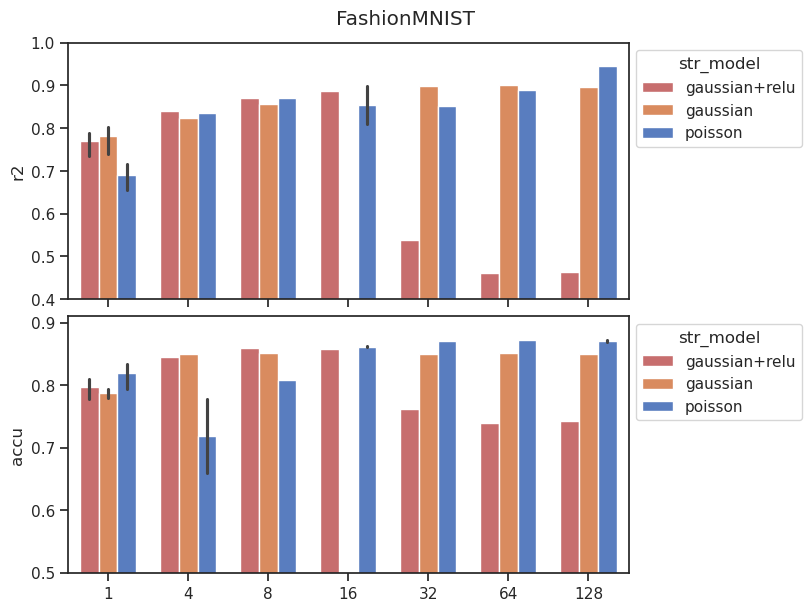

In [29]:
fig, axes = create_figure(2, 1, (8, 6), sharex='all')
fig.suptitle('FashionMNIST')

sns.barplot(
    data=_df,
    x='seq_len',
    hue='str_model',
    palette=get_palette_models(),
    y='r2',
    width=0.70,
    ax=axes[0],
)
sns.barplot(
    data=_df,
    x='seq_len',
    hue='str_model',
    palette=get_palette_models(),
    y='accu',
    width=0.70,
    ax=axes[1],
)
# axes[0].set(yscale='log')
axes[0].set(ylim=(0.4, 1.0))
axes[1].set(ylim=(0.5, 0.91))
for ax in axes.flat:
    ax.set(xlabel='')

move_legend(axes[0], (1, 1))
move_legend(axes[1], (1, 1))
plt.show()

### MNIST

In [30]:
_df = df.loc[
    (df['dataset'] == 'MNIST') &
    (df['seq_len'] == df['kl_beta'])
]
_df = _df.loc[_df['mse'] < 1000]
_df['str_model'] = _df['str_model'].str.replace(r'\+amort$', '', regex=True)

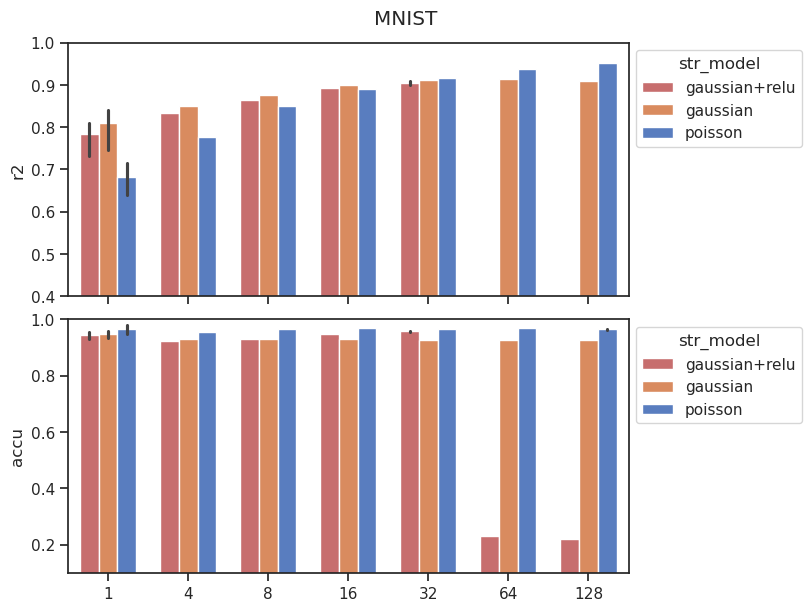

In [31]:
fig, axes = create_figure(2, 1, (8, 6), sharex='all')
fig.suptitle('MNIST')

sns.barplot(
    data=_df,
    x='seq_len',
    hue='str_model',
    palette=get_palette_models(),
    y='r2',
    width=0.70,
    ax=axes[0],
)
sns.barplot(
    data=_df,
    x='seq_len',
    hue='str_model',
    palette=get_palette_models(),
    y='accu',
    width=0.70,
    ax=axes[1],
)
# axes[0].set(yscale='log')
axes[0].set(ylim=(0.4, 1.0))
axes[1].set(ylim=(0.10, 1.0))
for ax in axes.flat:
    ax.set(xlabel='')

move_legend(axes[0], (1, 1))
move_legend(axes[1], (1, 1))
plt.show()